<a href="https://colab.research.google.com/github/hyperpipe-kr/colab-examples/blob/main/06_BERT_%EC%98%88%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 네이버 영화 리뷰 감성 분석 - BERT 파인튜닝

사전학습된 한국어 BERT 모델(`klue/bert-base`)을 네이버 영화 리뷰 데이터(NSMC)로 파인튜닝하여 감성 분석(긍정/부정) 분류기를 만듭니다.

- 모델: [klue/bert-base](https://huggingface.co/klue/bert-base)
- 데이터: [NSMC (Naver Sentiment Movie Corpus)](https://github.com/e9t/nsmc)
  - 훈련 데이터: 150,000건
  - 테스트 데이터: 50,000건

In [1]:
# 필요한 패키지 설치
!pip install transformers torch datasets pandas scikit-learn

## 1. 데이터 준비 및 전처리

In [2]:
import pandas as pd
import urllib.request

# 데이터 다운로드
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    filename="ratings_train.txt"
)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt",
    filename="ratings_test.txt"
)

# 데이터 로드
train_data = pd.read_table('ratings_train.txt')
test_data  = pd.read_table('ratings_test.txt')

print(f"훈련 데이터: {train_data.shape}, 테스트 데이터: {test_data.shape}")
train_data.head()

훈련 데이터: (150000, 3), 테스트 데이터: (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [3]:
# 결측값 제거
train_data = train_data.dropna(how='any')
test_data  = test_data.dropna(how='any')

print(f"결측값 제거 후 - 훈련: {len(train_data)}건, 테스트: {len(test_data)}건")
print(f"레이블 분포 (훈련):\n{train_data['label'].value_counts()}")

결측값 제거 후 - 훈련: 149995건, 테스트: 49997건
레이블 분포 (훈련):
label
0    75170
1    74825
Name: count, dtype: int64


In [4]:
# 학습 시간 단축을 위해 샘플링 (전체 데이터 사용 시 이 셀 생략)
# GPU 환경에서는 SAMPLE_SIZE = None 으로 설정하면 전체 데이터 사용
SAMPLE_SIZE = 10000  # None 이면 전체 데이터 사용

if SAMPLE_SIZE:
    train_data = train_data.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    test_data  = test_data.sample(n=SAMPLE_SIZE // 5, random_state=42).reset_index(drop=True)
    print(f"샘플링 후 - 훈련: {len(train_data)}건, 테스트: {len(test_data)}건")

샘플링 후 - 훈련: 10000건, 테스트: 2000건


## 2. 토크나이저 및 Dataset 준비

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

MODEL_NAME  = "klue/bert-base"
MAX_LEN     = 128
BATCH_SIZE  = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 토크나이징 예시
sample = tokenizer(
    "이 영화 정말 재미있었어요!",
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)
print("input_ids shape:", sample['input_ids'].shape)
print("decoded:", tokenizer.decode(sample['input_ids'][0]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

input_ids shape: torch.Size([1, 128])
decoded: [CLS] 이 영화 정말 재미있었어요! [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


In [6]:
class NSMCDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.texts  = dataframe['document'].tolist()
        self.labels = dataframe['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'token_type_ids': encoding['token_type_ids'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = NSMCDataset(train_data, tokenizer, MAX_LEN)
test_dataset  = NSMCDataset(test_data,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"훈련 배치 수: {len(train_loader)}, 테스트 배치 수: {len(test_loader)}")

훈련 배치 수: 313, 테스트 배치 수: 63


## 3. BERT 파인튜닝 모델 정의

In [7]:
from transformers import AutoModelForSequenceClassification

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

# 이진 분류(긍정/부정)를 위해 num_labels=2
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
model = model.to(device)
print("모델 파라미터 수:", sum(p.numel() for p in model.parameters() if p.requires_grad))

사용 디바이스: cuda


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

모델 파라미터 수: 110618882


## 4. 학습 설정 (Optimizer / Scheduler)

In [8]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS    = 3
LR        = 2e-5
WARMUP    = 0.1  # 전체 스텝의 10%를 warmup

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"총 스텝: {total_steps}, Warmup 스텝: {warmup_steps}")

총 스텝: 939, Warmup 스텝: 93


## 5. 학습 및 평가 함수

In [9]:
from sklearn.metrics import accuracy_score, classification_report


def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        preds = outputs.logits.argmax(dim=-1)
        total_loss += loss.item()
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels
            )

            preds = outputs.logits.argmax(dim=-1)
            total_loss += outputs.loss.item()
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy, all_preds, all_labels

## 6. 모델 학습

In [10]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, _, _ = evaluate(model, test_loader, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

Epoch 1/3 | Train Loss: 0.3956, Train Acc: 0.8157 | Val Loss: 0.3334, Val Acc: 0.8555
Epoch 2/3 | Train Loss: 0.2254, Train Acc: 0.9132 | Val Loss: 0.3113, Val Acc: 0.8800
Epoch 3/3 | Train Loss: 0.1389, Train Acc: 0.9511 | Val Loss: 0.3759, Val Acc: 0.8730


## 7. 최종 평가 및 결과 분석

In [11]:
_, final_acc, preds, labels = evaluate(model, test_loader, device)

print(f"\n===== 최종 테스트 정확도: {final_acc:.4f} ({final_acc*100:.2f}%) =====\n")
print(classification_report(labels, preds, target_names=['부정(0)', '긍정(1)']))


===== 최종 테스트 정확도: 0.8730 (87.30%) =====

              precision    recall  f1-score   support

       부정(0)       0.87      0.87      0.87       998
       긍정(1)       0.87      0.87      0.87      1002

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



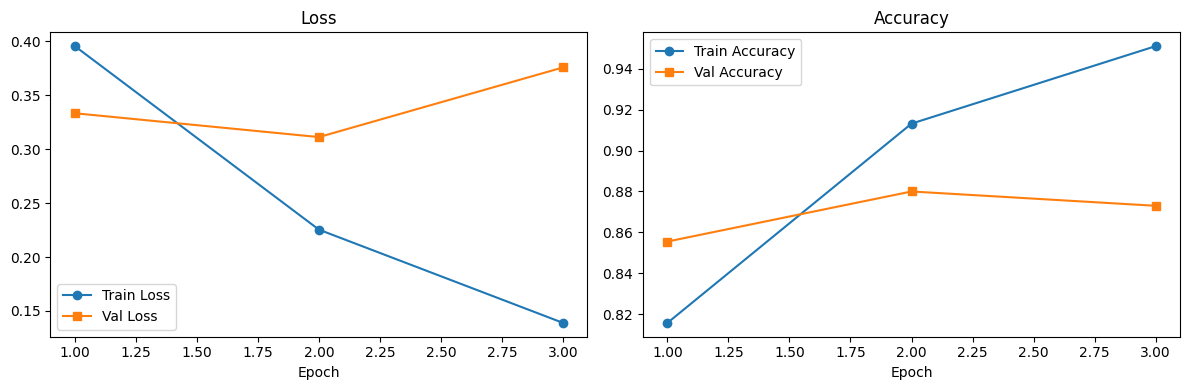

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   's-', label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train Accuracy')
axes[1].plot(epochs_range, history['val_acc'],   's-', label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. 모델 저장 및 추론 예시

In [13]:
# 모델 저장
model.save_pretrained('./nsmc_bert_finetuned')
tokenizer.save_pretrained('./nsmc_bert_finetuned')
print("모델 저장 완료: ./nsmc_bert_finetuned")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

모델 저장 완료: ./nsmc_bert_finetuned


In [14]:
def predict_sentiment(text, model, tokenizer, device, max_len=128):
    model.eval()
    encoding = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        outputs = model(
            input_ids=encoding['input_ids'].to(device),
            attention_mask=encoding['attention_mask'].to(device),
            token_type_ids=encoding['token_type_ids'].to(device)
        )
    probs = torch.softmax(outputs.logits, dim=-1).cpu().squeeze()
    label = probs.argmax().item()
    return {'label': '긍정' if label == 1 else '부정', 'score': probs[label].item()}


# 추론 예시
test_reviews = [
    "이 영화는 정말 최고입니다! 스토리도 훌륭하고 배우들의 연기도 완벽해요.",
    "시간 낭비였습니다. 스토리도 없고 지루하기만 해요.",
    "그냥 보통이에요. 나쁘지도 좋지도 않은 평범한 영화.",
]

print("===== 감성 분석 추론 예시 =====")
for review in test_reviews:
    result = predict_sentiment(review, model, tokenizer, device)
    print(f"[{result['label']} ({result['score']:.3f})] {review}")

===== 감성 분석 추론 예시 =====
[긍정 (0.997)] 이 영화는 정말 최고입니다! 스토리도 훌륭하고 배우들의 연기도 완벽해요.
[부정 (0.998)] 시간 낭비였습니다. 스토리도 없고 지루하기만 해요.
[부정 (0.996)] 그냥 보통이에요. 나쁘지도 좋지도 않은 평범한 영화.
